Montando drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importando as dependências

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from typing import List

Carregando o arquivo e visualizando os dados

In [3]:
dataADT = pd.read_csv('drive/MyDrive/TEES/Autism_Dataset_for_Toddlers.csv')
dataADT.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [4]:
dataADT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

Verificação de dados nulos

In [5]:
dataADT.isna().sum()

,0
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


Cenverter tipo da instância

In [6]:
le = LabelEncoder()
colToConvert = [
    'Class/ASD Traits ',
    'Jaundice',
    'Sex',
    'Family_mem_with_ASD'
]

for colum in colToConvert:
    dataADT[colum] = le.fit_transform(dataADT[colum])
    print(dataADT[colum].value_counts())
    print("-" * 40)

Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64
----------------------------------------
Jaundice
0    766
1    288
Name: count, dtype: int64
----------------------------------------
Sex
1    735
0    319
Name: count, dtype: int64
----------------------------------------
Family_mem_with_ASD
0    884
1    170
Name: count, dtype: int64
----------------------------------------


Avaliação do modelo

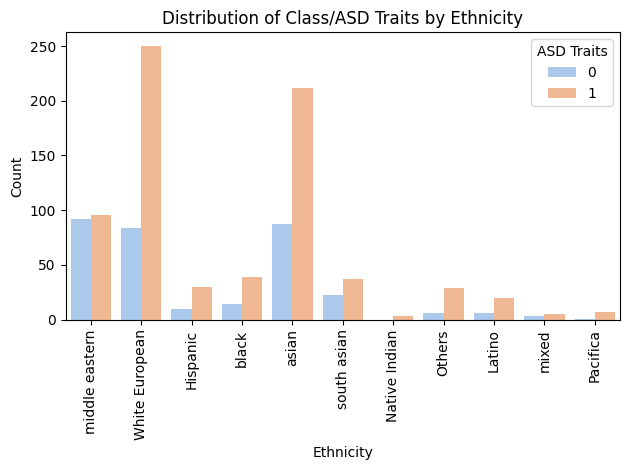

In [7]:
sns.countplot(data=dataADT, x='Ethnicity', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

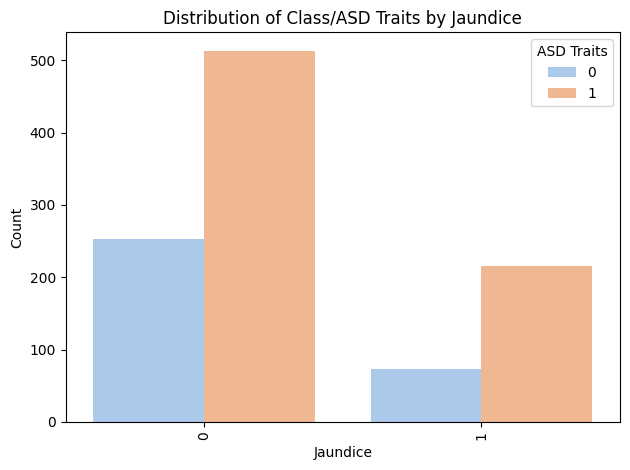

In [8]:
sns.countplot(data=dataADT, x='Jaundice', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Jaundice')
plt.xlabel('Jaundice')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

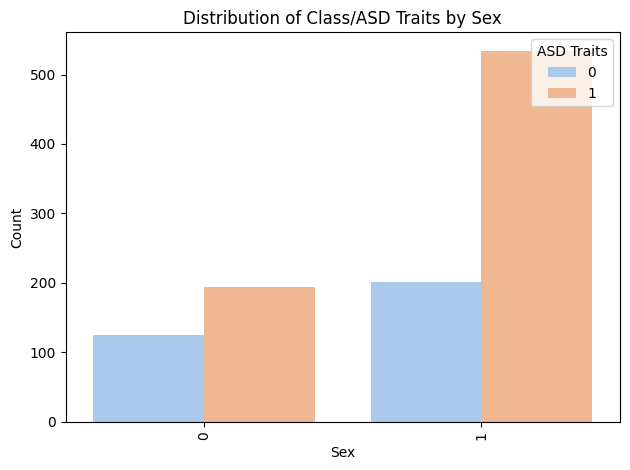

In [9]:
sns.countplot(data=dataADT, x='Sex', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

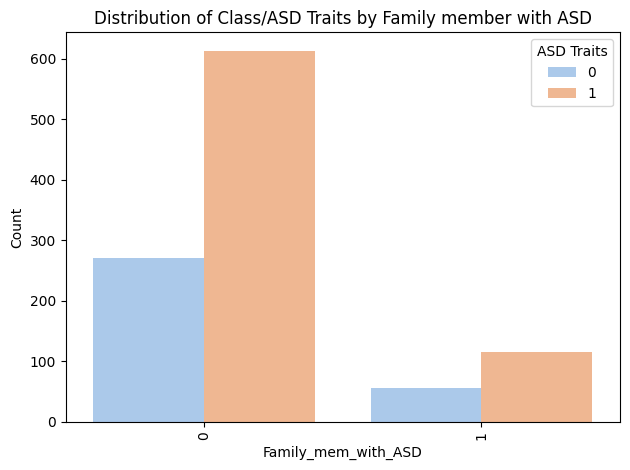

In [10]:
sns.countplot(data=dataADT, x='Family_mem_with_ASD', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Family member with ASD')
plt.xlabel('Family_mem_with_ASD')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

Boxplot

<Axes: >

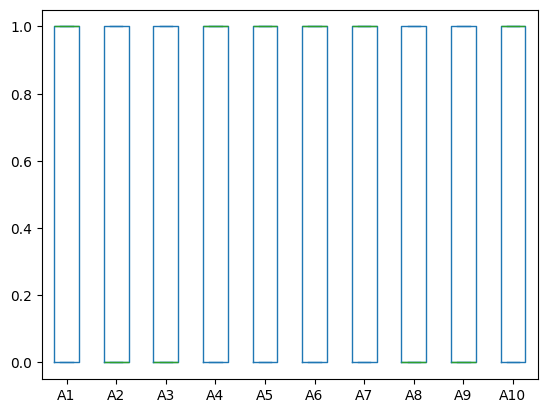

In [11]:
#separar em duas (caracteristicas comportamentais e caracteristicas individuais)
colBC = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
dataADT[colBC].plot(kind = 'box')

<Axes: >

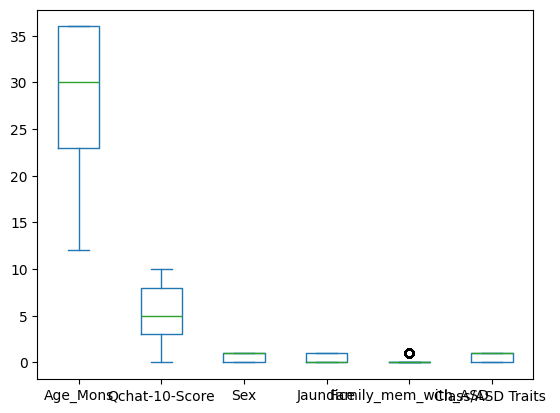

In [12]:
colIC = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
dataADT[colIC].plot(kind = 'box')

In [13]:
#sns.pairplot(dataADT[colBC], kind='kde')

In [14]:
#sns.pairplot(dataADT[colIC], kind='kde')

In [15]:
dataADT['Ethnicity'] = le.fit_transform(dataADT['Ethnicity'])

In [16]:
dataADT['Who completed the test'] = le.fit_transform(dataADT['Who completed the test'])

In [17]:
dataADT['Sex'] = le.fit_transform(dataADT['Sex'])

In [18]:
dataADT['Jaundice'] = le.fit_transform(dataADT['Jaundice'])

In [19]:
dataADT['Class/ASD Traits '] = le.fit_transform(dataADT['Class/ASD Traits '])

In [20]:
dataADT['Family_mem_with_ASD'] = le.fit_transform(dataADT['Family_mem_with_ASD'])

Criando modelo

In [21]:
entry = dataADT.drop('Class/ASD Traits ', axis=1)
desired_output = dataADT['Class/ASD Traits '].values

data_train, data_test, output_train, output_test = train_test_split(entry, desired_output, test_size=0.2)

In [22]:
sc = StandardScaler()
sc.fit(data_train)

data_train_standardized = sc.transform(data_train)
data_test_standardized = sc.transform(data_test)

In [23]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(data_train.shape[1],)))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
historyADT = model.fit(data_train_standardized, output_train, epochs=40, batch_size=32, validation_split=0.2)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8071 - loss: 0.4676 - val_accuracy: 0.9290 - val_loss: 0.2873
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9214 - loss: 0.2458 - val_accuracy: 0.9704 - val_loss: 0.1598
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9377 - loss: 0.1660 - val_accuracy: 0.9763 - val_loss: 0.1059
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9644 - loss: 0.1204 - val_accuracy: 0.9763 - val_loss: 0.0818
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9718 - loss: 0.0946 - val_accuracy: 0.9822 - val_loss: 0.0693
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9748 - loss: 0.0717 - val_accuracy: 0.9822 - val_loss: 0.0598
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9807 - loss: 0.0652 - val_accuracy: 0.9882 - val_loss: 0.0457
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9941 - loss: 0.0459 - val_accuracy: 0.9882 - val_loss

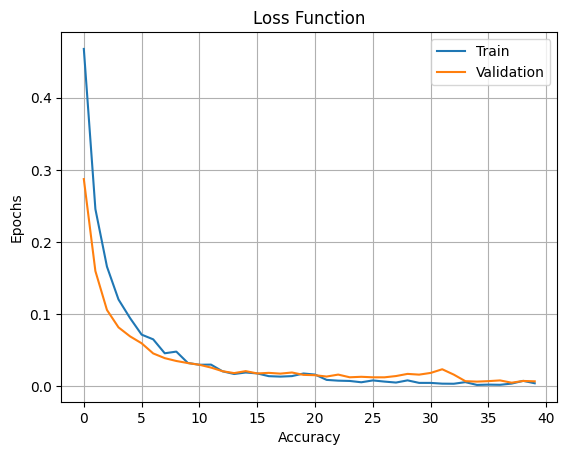

In [26]:
plt.plot(historyADT.history['loss'], label='Train')
plt.plot(historyADT.history['val_loss'], label='Validation')
plt.title('Loss Function')
plt.xlabel('Accuracy')
plt.ylabel('Epochs')
plt.legend()
#plt.yscale('log')
plt.grid(True)
plt.show()

In [27]:
output_proba = model.predict(data_test_standardized)

output_proba = output_proba.reshape(output_proba.shape[0])

output_pred = (output_proba > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [28]:
from sklearn.metrics import classification_report

print(classification_report(output_test, output_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        65
           1       0.99      0.99      0.99       146

    accuracy                           0.99       211
   macro avg       0.99      0.99      0.99       211
weighted avg       0.99      0.99      0.99       211



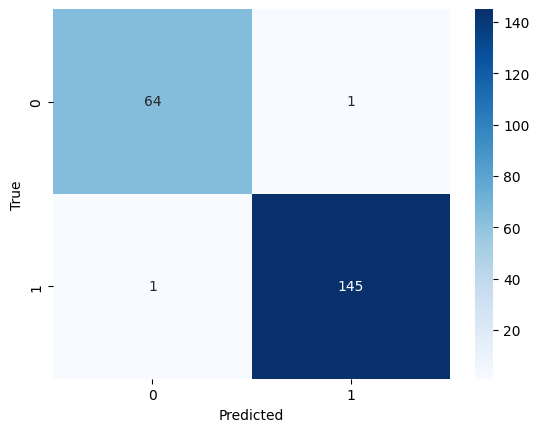

In [29]:
cm = confusion_matrix(output_test, output_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [30]:
def generate_profile(row):
  profile = []

  if row['A1'] == 1 or row['A2'] == 1:
    profile.append("social_interaction_difficulty")

  if row['A3'] == 1:
    profile.append("gestural_communication_difficulty")

  if row['A4'] == 1:
    profile.append("social_communication_difficulty")

  if row['A5'] == 1:
    profile.append("imagination_difficulty")

  if row['A6'] == 1:
    profile.append("joint_attention_difficulty")

  if row['A7'] == 1:
    profile.append("social_empathy_difficulty")

  if row['A8'] == 1:
    profile.append("atypical_language")

  if row['A9'] == 1:
    profile.append("non_verbal_communication_difficulty")

  if row['A10'] == 1:
    profile.append("atypical_attention")

  return profile

In [31]:
def recommend_strategies(profile):
  """Recommend evidence-based strategies based on specific difficulties from the dataset."""

  strategies = []

  if "social_interaction_difficulty" in profile:
    strategies.extend([
        "Posicionar-se na altura dos olhos da criança",
        "Utilizar objetos atrativos para direcionar o olhar",
        "Chamar a criança pelo nome com estímulo visual/tátil",
        "Reforçar contato visual e resposta ao chamado"
  ])

  if "gestural_communication_difficulty" in profile:
    strategies.extend([
        "Modelar gestos simples repetidamente",
        "Guiar a mão da criança (hand-over-hand) para ensinar gestos",
        "Criar rotinas que exijam gestos",
        "Reforçar tentativas de gestos"
  ])

  if "social_communication_difficulty" in profile:
    strategies.extend([
        "Criar oportunidades estruturadas para iniciar interações",
        "Ensinar frases específicas para iniciar brincadeiras",
        "Utilizar parceiros de pares treinados"
    ])

  if "imagination_difficulty" in profile:
    strategies.extend([
        "Começar com brincadeiras funcionais (uso real de objetos)",
        "Modelar brincadeiras simbólicas simples",
        "Utilizar fantoches para demonstrar ações imaginárias"
    ])

  if "joint_attention_difficulty" in profile:
    strategies.extend([
        "Seguir o olhar da criança e comentar o que ela observa",
        "Utilizar brinquedos que exigem interação conjunta",
        "Apontar e incentivar a criança a olhar",
        "Reforçar olhar alternado entre objeto e adulto"
    ])

  if "social_empathy_difficulty" in profile:
    strategies.extend([
        "Ensinar emoções básicas com flashcards",
        "Utilizar vídeos de crianças expressando emoções",
        "Praticar identificação de emoções em fotos de familiares"
    ])

  if "atypical_language" in profile:
    strategies.extend([
        "Utilizar sistemas de comunicação aumentativa (PECS)",
        "Modelar frases curtas e simples",
        "Responder à ecolalia com a resposta correta"
    ])

  if "non_verbal_communication_difficulty" in profile:
    strategies.extend([
        "Jogos de adivinhação de emoções",
        "Utilizar espelho para praticar expressões",
         "Assistir vídeos e perguntar 'como ele está se sentindo?'"
    ])

  if "atypical_attention" in profile:
    strategies.extend([
        "Usar interesses especiais como motivadores",
        "Estruturar ambiente com poucas distrações",
        "Dividir tarefas com pausas programadas",
         "Utilizar cronômetro visual"
     ])

  return list(set(strategies))

In [32]:
def define_level(prob: float) -> str:
  """Define support level based on probability score."""
  if prob > 0.8:
    return "high support"
  if prob > 0.5:
    return "moderate support"
  return "low support"

In [33]:
def educational_system(model, scaler, input_df):
  input_scaled = scaler.transform(input_df)

  proba = model.predict(input_scaled)
  pred = (proba > 0.5).astype(int)

  results = []
  for i, (idx, row) in enumerate(input_df.iterrows()):
    profile = generate_profile(row)

    results.append({
        "autism_probability": float(proba[i][0]),
        "model_prediction": int(pred[i][0]),
        "support_level": define_level(proba[i][0]),
        "profile": profile,
        "recommended_strategies": recommend_strategies(profile)
    })

  return results

In [34]:
single_example = data_test.iloc[0:1]
single_result = educational_system(model, sc, single_example)
print("Single Sample Result:", single_result)

multiple_examples = data_test.iloc[0:5]
multiple_results = educational_system(model, sc, multiple_examples)

for i, result in enumerate(multiple_results):
    print(f"\n--- Sample {i+1} ---")
    print(f"Probability: {result['autism_probability']:.4f}")
    print(f"Prediction: {result['model_prediction']}")
    print(f"Support Level: {result['support_level']}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Single Sample Result: [{'autism_probability': 0.9999700784683228, 'model_prediction': 1, 'support_level': 'high support', 'profile': ['social_interaction_difficulty', 'gestural_communication_difficulty', 'social_empathy_difficulty', 'atypical_language', 'non_verbal_communication_difficulty'], 'recommended_strategies': ['Modelar frases curtas e simples', 'Utilizar espelho para praticar expressões', 'Reforçar contato visual e resposta ao chamado', 'Reforçar tentativas de gestos', 'Jogos de adivinhação de emoções', 'Utilizar objetos atrativos para direcionar o olhar', 'Modelar gestos simples repetidamente', 'Posicionar-se na altura dos olhos da criança', 'Utilizar sistemas de comunicação aumentativa (PECS)', 'Responder à ecolalia com a resposta correta', "Assistir vídeos e perguntar 'como ele está se sentindo?'", 'Guiar a mão da criança (hand-over-hand) para ensinar gestos', 'Ensinar emoções básicas com flashcards', 'Praticar identificação de emoções 

In [35]:
example = data_test.iloc[0:1]

result = educational_system(model, sc, example)

print("Result:", result)
print("\nAutism Probability:", result[0]["autism_probability"])
print("Model Prediction:", result[0]["model_prediction"])
print("Support Level:", result[0]["support_level"])
print("Profile:", result[0]["profile"])
print("Recommended Strategies:", result[0]["recommended_strategies"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Result: [{'autism_probability': 0.9999700784683228, 'model_prediction': 1, 'support_level': 'high support', 'profile': ['social_interaction_difficulty', 'gestural_communication_difficulty', 'social_empathy_difficulty', 'atypical_language', 'non_verbal_communication_difficulty'], 'recommended_strategies': ['Modelar frases curtas e simples', 'Utilizar espelho para praticar expressões', 'Reforçar contato visual e resposta ao chamado', 'Reforçar tentativas de gestos', 'Jogos de adivinhação de emoções', 'Utilizar objetos atrativos para direcionar o olhar', 'Modelar gestos simples repetidamente', 'Posicionar-se na altura dos olhos da criança', 'Utilizar sistemas de comunicação aumentativa (PECS)', 'Responder à ecolalia com a resposta correta', "Assistir vídeos e perguntar 'como ele está se sentindo?'", 'Guiar a mão da criança (hand-over-hand) para ensinar gestos', 'Ensinar emoções básicas com flashcards', 'Praticar identificação de emoções em fotos de fa

In [36]:
print(model.predict(data_test_standardized[:10]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[9.9997008e-01]
 [9.9999988e-01]
 [1.2411441e-08]
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]
 [3.0588226e-06]
 [9.9999613e-01]]


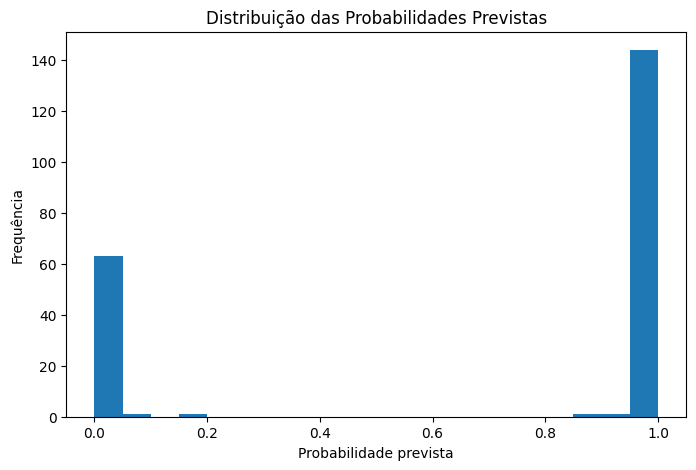

In [37]:
plt.figure(figsize=(8,5))
plt.hist(output_proba, bins=20)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência")
plt.title("Distribuição das Probabilidades Previstas")
plt.show()

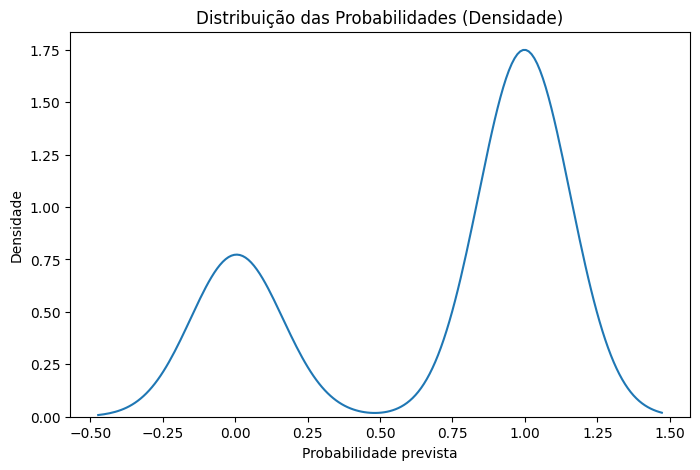

In [38]:
plt.figure(figsize=(8,5))
sns.kdeplot(output_proba)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Densidade")
plt.title("Distribuição das Probabilidades (Densidade)")
plt.show()

<Axes: >

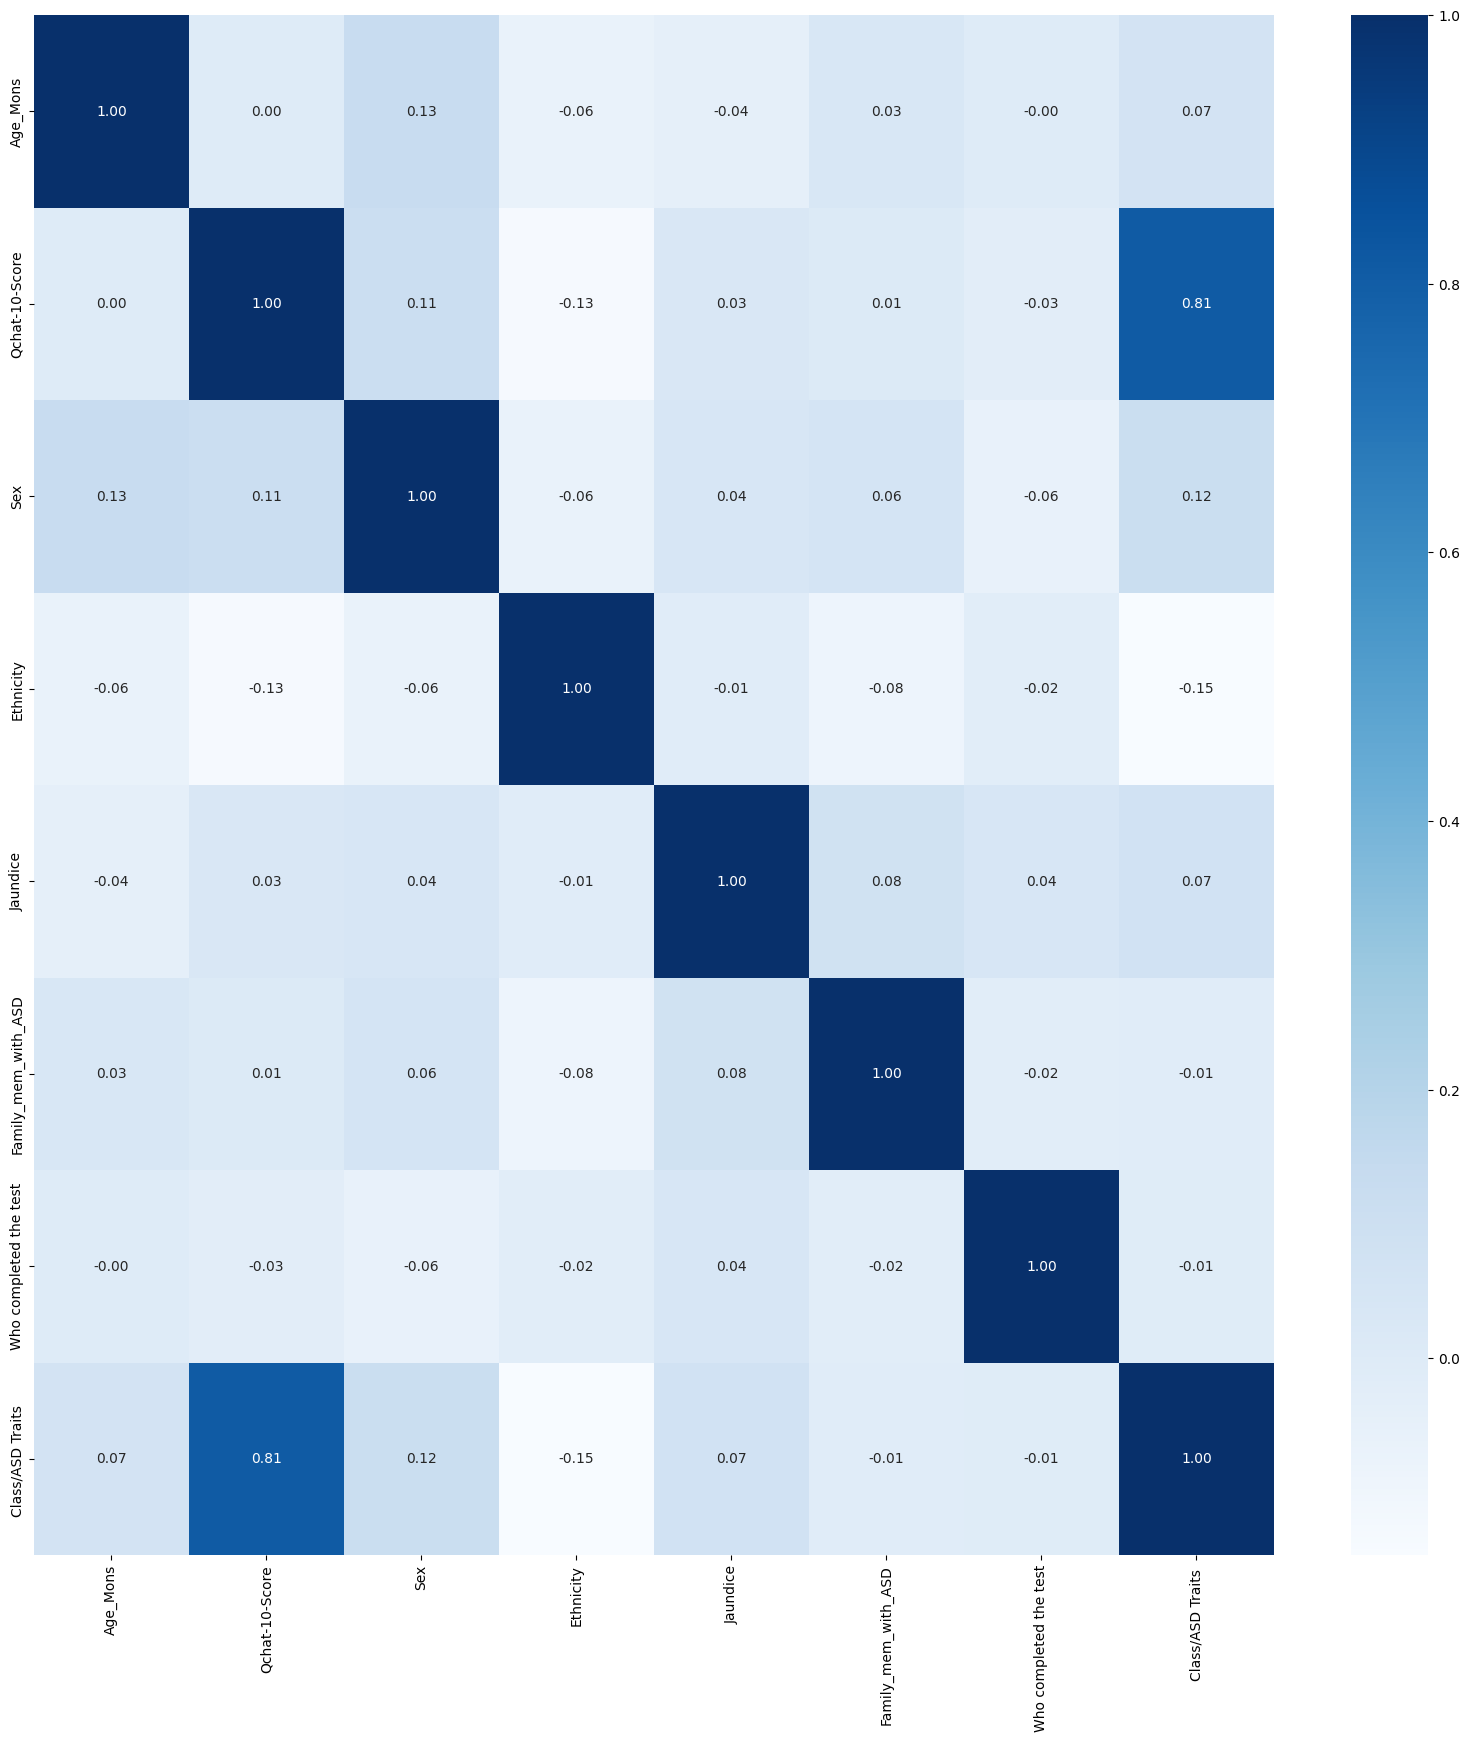

In [39]:
attributes = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
corr = dataADT[attributes].corr()
plt.figure(figsize = (20,20))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues')

In [40]:
print(dataADT['Class/ASD Traits '].value_counts())


Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64


In [41]:
data_train.shape

(843, 18)

In [42]:
pd.Series(output_train).value_counts()

,count
1,582
0,261
